In [9]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import mplcursors
from PIL import Image
from pdf2image import convert_from_path

from pathlib import Path
from sklearn.preprocessing import StandardScaler
import umap

In [2]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/*/qtransform_features.parquet"))

MONTH_ORDER = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6, "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}

In [5]:
if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}")

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

parquet_files = list(DATA_DIR.glob("*/*/qtransform_features.parquet"))
parquet_files.sort(key=lambda p: (int(p.parent.parent.name), MONTH_ORDER[p.parent.name]))

for file in parquet_files:
    print(f"Loading: {file}")

    df = pd.read_parquet(file)
    folder = file.parent

    image_paths = [str(folder / f"qtransform_{i:06d}.pdf")for i in range(len(df))]
    missing_images = [path for path in image_paths if not Path(path).exists()]

    if missing_images:
        raise FileNotFoundError(f"{len(missing_images)} PDF files are missing in {folder}. First missing file: {missing_images[0]}")

    df["image_path"] = image_paths
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Found 48 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_par

In [6]:
reducer = umap.UMAP() 

In [7]:
embedded = reducer.fit_transform(X_scaled)
embedded.shape

(30704, 2)

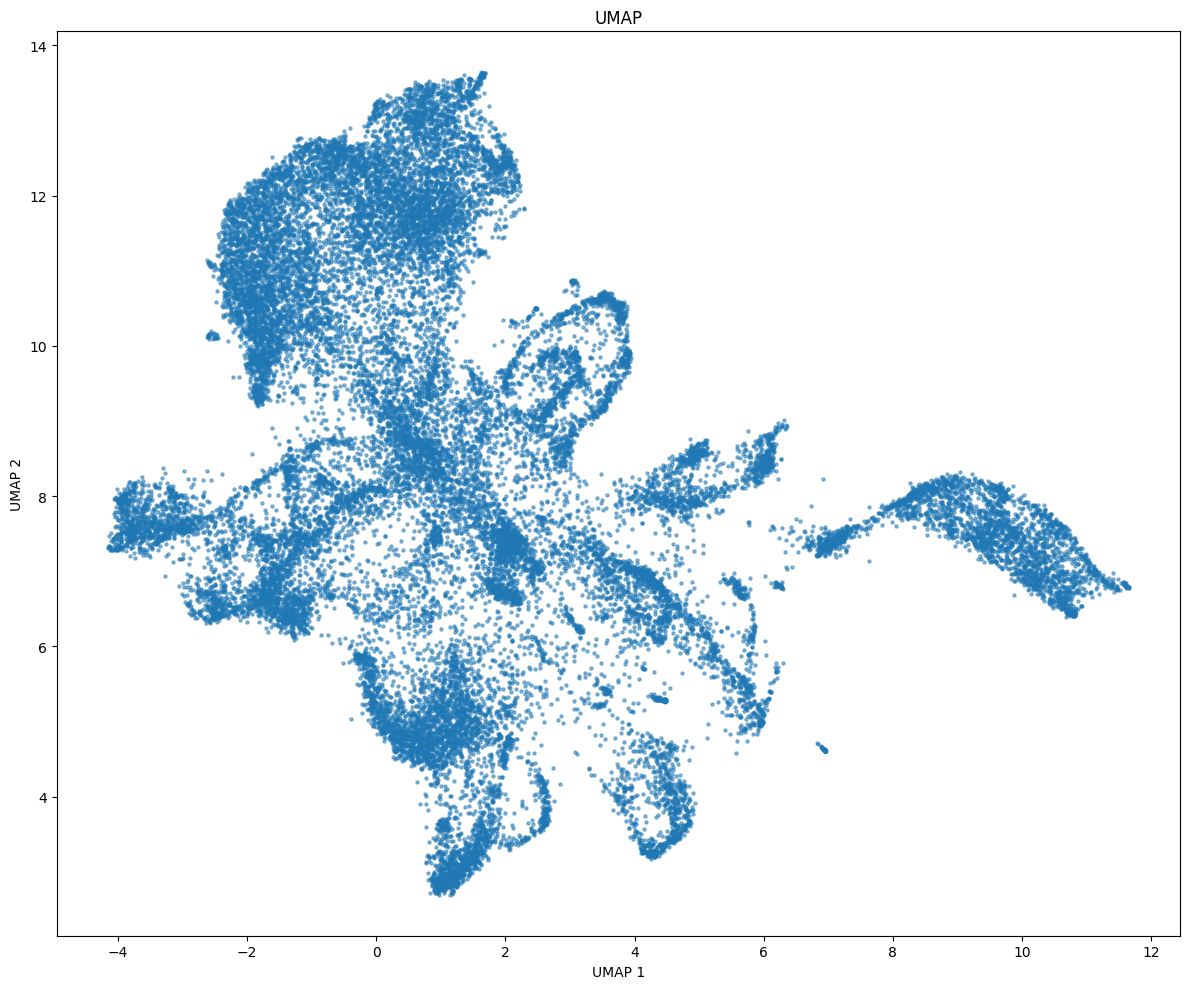

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embedded[:, 0], embedded[:, 1],s=5,alpha=0.5)
ax.set_title(f"UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

Spearman correlation = 0.5155
p-value = 0.0000e+00


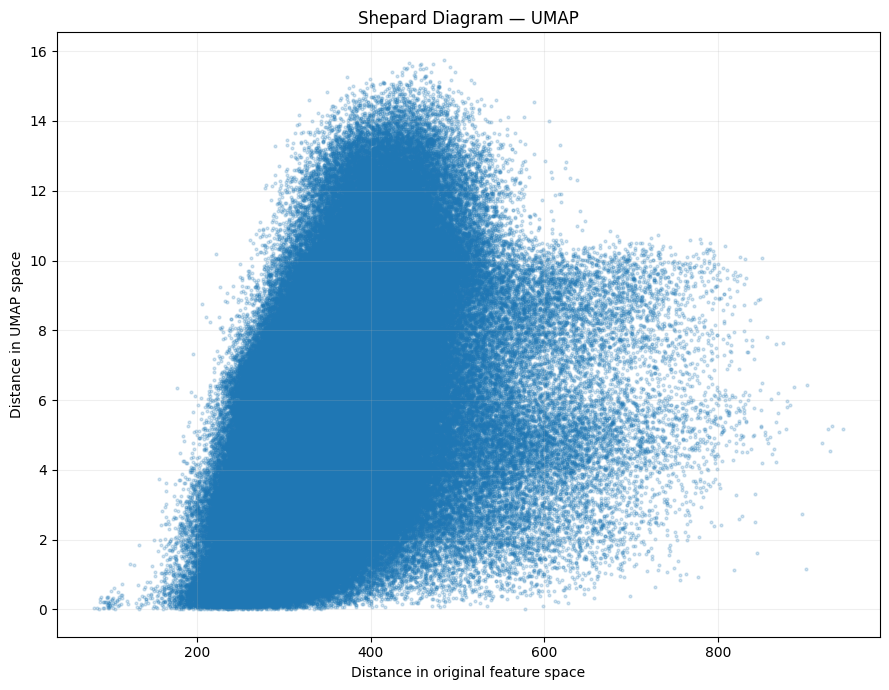

In [10]:
RANDOM_STATE = 42
N_PAIRS = 500000

rng = np.random.default_rng(RANDOM_STATE)
N = X.shape[0]

idx1 = rng.integers(0, N, size=N_PAIRS)
idx2 = rng.integers(0, N, size=N_PAIRS)

mask = idx1 != idx2
idx1 = idx1[mask]
idx2 = idx2[mask]

d_original = np.linalg.norm(X[idx1] - X[idx2],axis=1)
d_tsne = np.linalg.norm(embedded[idx1] - embedded[idx2],axis=1)

rho, pvalue = spearmanr(d_original, d_tsne)
print(f"Spearman correlation = {rho:.4f}")
print(f"p-value = {pvalue:.4e}")

plt.figure(figsize=(9, 7))
plt.scatter(d_original,d_tsne,s=4,alpha=0.2)
plt.xlabel("Distance in original feature space")
plt.ylabel("Distance in UMAP space")
plt.title("Shepard Diagram — UMAP")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.plot()
plt.savefig("UMAP_shepred_diagram.pdf")